In [1]:
import sys
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D

%load_ext autoreload
%autoreload 2

sys.path.insert(0, "..")
from plasmidtools import examplots, helpers


Paths

In [2]:
DATA_DIR = Path("../data")
FIG_DIR = DATA_DIR / "figures"
ADDGENE_DIR = DATA_DIR / "addgene"
GBK_DIR = DATA_DIR / "genbank"


Pre-processed data

In [3]:
plasmid_meta = pl.read_csv(ADDGENE_DIR / "mammalian_plasmids.tsv", separator="\t")
plasmid_citations = pl.read_parquet(ADDGENE_DIR / "citations_addgene.parquet")
plasmid_stats = (
    pl.read_parquet(ADDGENE_DIR / "mammalian_plasmids_statistics.parquet")
    .join(plasmid_meta[["sequence_id", "plasmid_id", "plasmid_name"]], on="sequence_id", how="left")
)

cre_annotation = pl.read_parquet(ADDGENE_DIR / "mammalian_plasmids_cre_and_tss.parquet")


Pre-calculated predictions

In [4]:
CREST_TILE_ENCOD = ADDGENE_DIR / "mammalian_plasmids_crest_encodings.parquet"
CREST_TILE_PREDS = ADDGENE_DIR / "mammalian_plasmids_crest_preds.parquet"
CELL_TYPES = ["HEK293T", "A549", "MRC5", "SHSY5Y", "K562", "GM12878"]  # ["HEK293T", "A549", "MRC5", "SHSY5Y", "K562", "GM12878", "Jurkat"]

PUFFIN_PREDS = ADDGENE_DIR / "mammalian_plasmids_puffin_preds.h5"

# Load CREST predictions
tile_encoding = pl.read_parquet(CREST_TILE_ENCOD)
cre_predictions = pl.read_parquet(CREST_TILE_PREDS)
n_crest_tiles = tile_encoding["tile_ids"].list.max().max() + 1
crest_pred_dct = {}
for cell in CELL_TYPES:
    tile_preds = np.full(n_crest_tiles, np.nan)
    tile_preds[cre_predictions["tile_ID"].to_numpy()] = cre_predictions[cell].to_numpy()
    crest_pred_dct[cell] = tile_preds

# Load Puffin indices
with h5py.File(PUFFIN_PREDS, "r") as h5f:
    puffin_feat_names = h5f.attrs["features"]
    puffin_fwd_idx = int(np.argwhere(puffin_feat_names == "FANTOM_CAGE fwd")[0, 0])
    puffin_rev_idx = int(np.argwhere(puffin_feat_names == "FANTOM_CAGE rev")[0, 0])


### Visualization of predictions

Load plasmid data: genbank, CREST predictions, Puffin predictions

In [5]:
# Extract plasmid GBK to a separate file
PLASMID_ID = 99297

COMBINED_GBK = ADDGENE_DIR / "mammalian_plasmids.gbk"
# `gbk_name` (sequence-<id>-) stays the lookup key into the pre-computed
# prediction tables; only the on-disk filename follows the Addgene_<id>.gbk
# convention used by scripts/sequencing_map.sh.
gbk_name = plasmid_stats.filter(pl.col("plasmid_id") == PLASMID_ID)["gbk_name"][0]
gbk_file = GBK_DIR / f"Addgene_{PLASMID_ID}.gbk"
helpers.extract_genbank_record_by_name(COMBINED_GBK, gbk_name, gbk_file)

# Plasmid CREST predictions
tile_ids_plasmid = tile_encoding.filter(pl.col("gbk_name") == gbk_name)["tile_ids"][0]
plasmid_crest_preds = {cell: preds[tile_ids_plasmid] for cell, preds in crest_pred_dct.items()}

# Plasmid Puffin predictions
with h5py.File(PUFFIN_PREDS, "r") as h5f:
    puffin_preds = h5f[gbk_name][:]
    puffin_fwd_preds = puffin_preds[puffin_fwd_idx]
    puffin_rev_preds = puffin_preds[puffin_rev_idx]

# Peaks (CREs and TSSs)
plasmid_peaks = cre_annotation.filter(pl.col("gbk_name") == gbk_name)
plasmid_crest_peaks = {cell: plasmid_peaks[f"CREST ({cell})"].to_list() for cell in CELL_TYPES}
plasmid_fwd_tss = plasmid_peaks["Puffin (FANTOM_CAGE_fwd)"].to_list()
plasmid_rev_tss = plasmid_peaks["Puffin (FANTOM_CAGE_rev)"].to_list()

Output file exists, exiting.


Plot tracks (only HEK293T)

In [6]:
ax = examplots.plot_backbone(gbk_file)
examplots.plot_track(ax, puffin_fwd_preds, track_color="firebrick", track_base_radius=1.3, track_label="FANTOM_CAGE fwd (Puffin)", k_norm=.25, direction="cw")
examplots.plot_track(ax, puffin_rev_preds, track_color="orange", track_base_radius=1.7, track_label="FANTOM_CAGE rev (Puffin)", k_norm=.25, direction="ccw")
examplots.plot_track(ax, plasmid_crest_preds["HEK293T"], track_color="forestgreen", track_base_radius=2.1, track_label="HEK293T (CREST)", k_norm=5)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.2, 1.05), title="Prediction Tracks", frameon=False)
plt.close()


Plot heatmaps (all cell types)

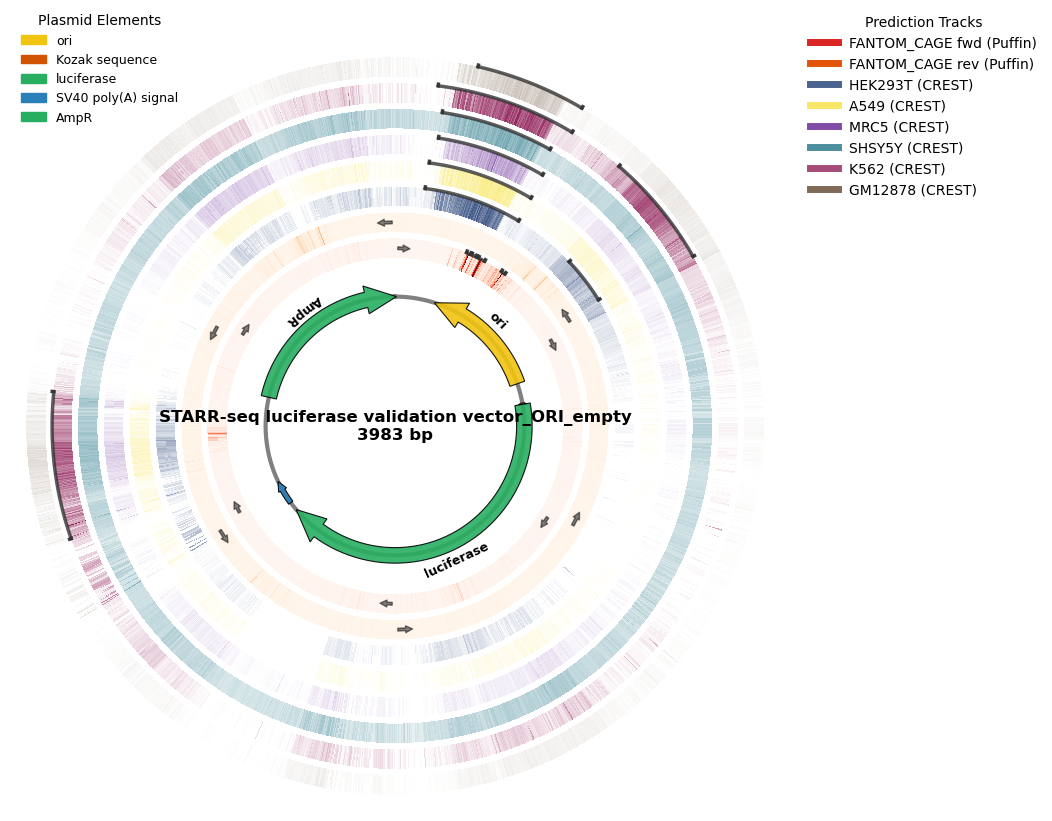

In [7]:
ax = examplots.plot_backbone(gbk_file)
track_width = 0.15  # thickness of each circular heatmap

# Plot Puffin tracks using red/orange sequential colormaps
examplots.plot_track_heatmap(ax, puffin_fwd_preds, cmap="Reds", track_base_radius=1.3, track_width=track_width, track_label="FANTOM_CAGE fwd (Puffin)", k_norm=0.25, direction="cw")
examplots.plot_peak_annotation(ax, plasmid_fwd_tss, seq_len=len(puffin_fwd_preds), track_base_radius=1.3, track_width=track_width)

examplots.plot_track_heatmap(ax, puffin_rev_preds, cmap="Oranges", track_base_radius=1.5, track_width=track_width, track_label="FANTOM_CAGE rev (Puffin)", k_norm=0.25, direction="ccw")
examplots.plot_peak_annotation(ax, plasmid_rev_tss, seq_len=len(puffin_rev_preds), track_base_radius=1.5, track_width=track_width)

# Custom colormaps: exact white at 0, moving to a rich, dark hue at maximum value
crest_cmaps = [
    LinearSegmentedColormap.from_list("c_blue", ["white", "#002060"]),  # Deep Royal Navy
    LinearSegmentedColormap.from_list("c_yellow", ["white", "#f5dd27"]),  # Yellow
    LinearSegmentedColormap.from_list("c_purple", ["white", "#4b0082"]),  # Deep Indigo/Purple
    LinearSegmentedColormap.from_list("c_teal", ["white", "#005f73"]),  # Dark Mediterranean Teal
    LinearSegmentedColormap.from_list("c_magenta", ["white", "#800040"]),  # Deep Wine/Plum Magenta
    LinearSegmentedColormap.from_list("c_brown", ["white", "#4a2c11"]),  # Dark Chocolate Brown
    LinearSegmentedColormap.from_list("c_green", ["white", "#21a639"])  # Forest Green
]

crest_base_r = 1.7  # Starting radius for the first CREST track

for i, cell in enumerate(CELL_TYPES):
    current_radius = crest_base_r + (i * (track_width + 0.05))  # 0.05 padding between rings
    examplots.plot_track_heatmap(ax, plasmid_crest_preds[cell], cmap=crest_cmaps[i], track_base_radius=current_radius, track_width=track_width, track_label=f"{cell} (CREST)", k_norm=6)
    examplots.plot_peak_annotation(ax, plasmid_crest_peaks[cell], seq_len=len(plasmid_crest_preds[cell]), track_base_radius=current_radius, track_width=track_width)

# Render legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.35, 1.05), title="Prediction Tracks", frameon=False)


**Linear Plots: zoom-in**

/projectnb/vtrs/joseff/plasmids/notebooks/../plasmidtools/examplots.py:648: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(FancyArrow(s, y,  span, 0, **arrow_kw))
/projectnb/vtrs/joseff/plasmids/notebooks/../plasmidtools/examplots.py:646: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(FancyArrow(e, y, -span, 0, **arrow_kw))


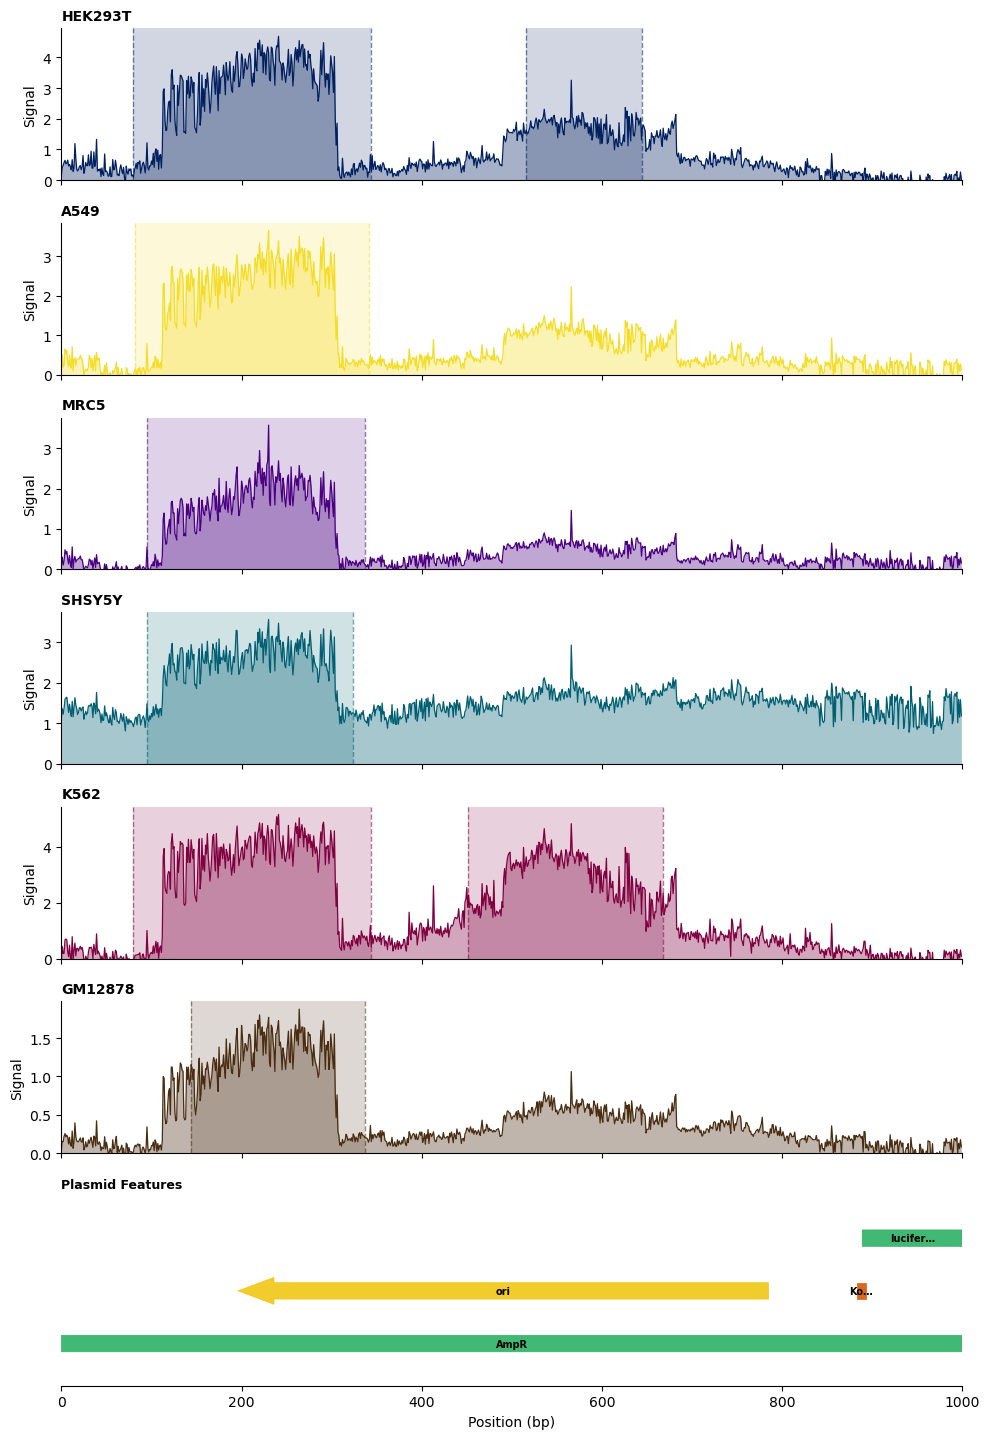

In [8]:
start_bp, end_bp = 0, 1000
colors = ["#002060", "#f5dd27", "#4b0082", "#005f73", "#800040", "#4a2c11", "#21a639"]

# # single track
# examplots.plot_track_linear(
#     plasmid_crest_preds["K562"], 0, 1000,
#     peaks=plasmid_crest_peaks["K562"],
#     label="K562 (CREST)", color="#002060"
# )

n_cells = len(CELL_TYPES)
fig, axes = plt.subplots(
    n_cells + 1, 1,
    figsize=(10, 2.0 * n_cells + 2.5),
    sharex=True,
    gridspec_kw={"height_ratios": [2] * n_cells + [2.5]},
)
fig.subplots_adjust(hspace=0.12)

for ax, cell, color in zip(axes[:-1], CELL_TYPES, colors):
    examplots.plot_track_linear(
        plasmid_crest_preds[cell], start_bp, end_bp,
        peaks=plasmid_crest_peaks[cell],
        label=cell, color=color, ax=ax,
    )
    ax.set_xlabel("")   # suppress x-label on all but the bottom panel

examplots.plot_linear_features(gbk_file, start_bp, end_bp, ax=axes[-1])
plt.tight_layout()

### Validation with real sequencing data

**STAP-seq (Muerdter et al., Nat Methods 2017)**

Load the experimental track and the matching predictions

In [9]:
# =============================================================================
# Experimental STAP-seq TSS track vs. predictions
#
# STAP-seq exists only for the five hSTARR-seq core-promoter vectors
# (Addgene 99291-99295); see data/sequencing/readme.md. Produced by
# scripts/sequencing_download.sh followed by scripts/sequencing_map.sh.
# =============================================================================

STAP_PLASMID_ID = 99291  # 99291 mCP | 99292 SCP1 | 99293 TFF2 | 99294 SULT1C2 | 99295 OCT4
N_STAP_PEAKS = 8  # top initiation sites to annotate on the ring

STAP_TRACK_FILE = DATA_DIR / "sequencing" / "mapped" / "PMID-29256496.txt"

if not STAP_TRACK_FILE.exists():
    raise FileNotFoundError(
        f"{STAP_TRACK_FILE} not found - run scripts/sequencing_download.sh, "
        "then scripts/sequencing_map.sh"
    )

stap_tracks = helpers.load_stap_tracks(STAP_TRACK_FILE)
if STAP_PLASMID_ID not in stap_tracks:
    raise KeyError(
        f"No STAP-seq track for Addgene {STAP_PLASMID_ID}; "
        f"available: {sorted(stap_tracks)}"
    )
stap_header, stap_counts = stap_tracks[STAP_PLASMID_ID]

# Prediction data for the same plasmid (mirrors the extraction cell above)
stap_gbk_name = plasmid_stats.filter(pl.col("plasmid_id") == STAP_PLASMID_ID)["gbk_name"][0]
stap_gbk_file = GBK_DIR / f"Addgene_{STAP_PLASMID_ID}.gbk"
helpers.extract_genbank_record_by_name(COMBINED_GBK, stap_gbk_name, stap_gbk_file)

stap_tile_ids = tile_encoding.filter(pl.col("gbk_name") == stap_gbk_name)["tile_ids"][0]
stap_crest_preds = {cell: preds[stap_tile_ids] for cell, preds in crest_pred_dct.items()}

with h5py.File(PUFFIN_PREDS, "r") as h5f:
    stap_puffin = h5f[stap_gbk_name][:]
    stap_puffin_fwd = stap_puffin[puffin_fwd_idx]
    stap_puffin_rev = stap_puffin[puffin_rev_idx]

stap_pred_peaks = cre_annotation.filter(pl.col("gbk_name") == stap_gbk_name)
stap_crest_peaks = {cell: stap_pred_peaks[f"CREST ({cell})"].to_list() for cell in CELL_TYPES}
stap_fwd_tss = stap_pred_peaks["Puffin (FANTOM_CAGE_fwd)"].to_list()
stap_rev_tss = stap_pred_peaks["Puffin (FANTOM_CAGE_rev)"].to_list()

# The experimental track and the predictions must share a coordinate frame:
# both are arrays over the same deposited sequence, index 0 == plasmid bp 1.
assert len(stap_counts) == len(stap_puffin_fwd), (
    f"track is {len(stap_counts)} bp but predictions are {len(stap_puffin_fwd)} bp - "
    "the GenBank record used for mapping differs from the one used for predictions"
)

stap_peaks = examplots.stap_peak_intervals(stap_counts, N_STAP_PEAKS)

print(f"{stap_header['vector']}  (Addgene {STAP_PLASMID_ID}, {stap_header['core_promoter']} core promoter)")
print(f"  {len(stap_counts)} bp, {int(stap_header['molecules']):,} molecules "
      f"from {int(stap_header['reads_fwd']):,} forward reads "
      f"(duplicate rate {float(stap_header['duplicate_rate']):.1%})")
print(f"  top {N_STAP_PEAKS} initiation sites -> {len(stap_peaks)} peak(s): {stap_peaks}")
print(f"  Puffin FANTOM_CAGE fwd predicted TSSs: {stap_fwd_tss[0]}")

Output file exists, exiting.
hSTARR-seq_mCP  (Addgene 99291, mCP core promoter)
  4274 bp, 30,807 molecules from 492,657 forward reads (duplicate rate 93.8%)
  top 8 initiation sites -> 4 peak(s): [[4155, 4158], [4173, 4174], [4184, 4185], [4201, 4206]]
  Puffin FANTOM_CAGE fwd predicted TSSs: [[7, 22], [4147, 4162], [4166, 4182], [4191, 4215]]


Circular heatmap: predictions vs. experimental TSSs

**Masked region: the AgeI/SalI cloning site.** Each deposited backbone carries a
CmR–ccdB stuffer between its single AgeI (`ACCGGT`) and single SalI (`GTCGAC`) site.
In the transfected libraries that cassette is replaced by a BAC-derived human
fragment, so predictions in this window describe DNA that was never present in the
assayed molecules. The window is blanked out of the figure rather than compared.

Positions below are 1-based inclusive, spanning the AgeI site through the SalI site.
Each is bracketed by the record's own annotated `CmR` and `ccdB` CDSs, and the span
is 1,473 bp in all five vectors — the same cassette, differently rotated.

Sources: coordinates and CDS spans are read from the deposited Addgene GenBank
records in `data/genbank/Addgene_<id>.gbk`; the AgeI/SalI cloning strategy is
recorded in the vector description of Muerdter et al. 2018 (PMID 29256496).

Output file exists, exiting.


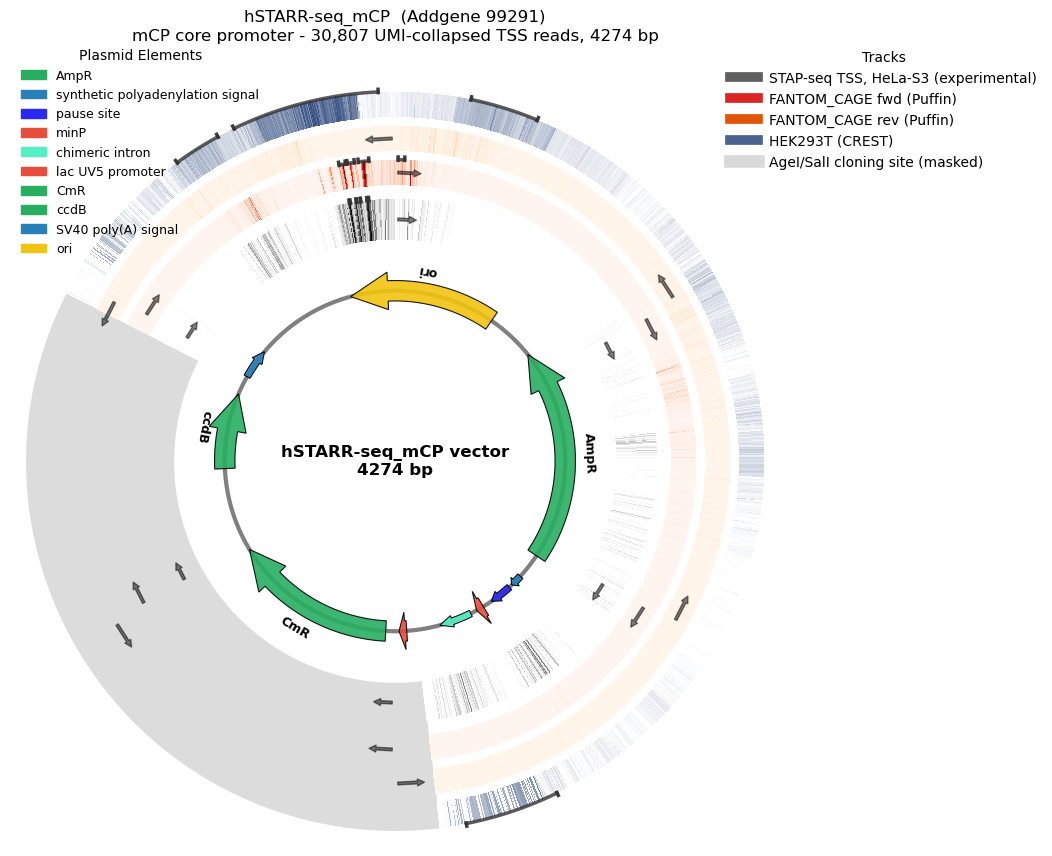

In [10]:
MASK_WINDOWS = {  # 1-based inclusive, AgeI site through SalI site. 99294 wraps the origin.
    99291: (2055, 3527),
    99292: (412, 1884),
    99293: (1761, 3233),
    99294: (3108, 256),
    99295: (422, 1894),
}

PANEL_PLASMIDS = [99291, 99292, 99293, 99294, 99295]
PANEL_CELLS = ["HEK293T"]  # one CREST ring per cell type, stacked outwards

# Colour a cell type the same way as the all-cell-types heatmap above, so adding
# a cell here does not recolour the ones already drawn.
crest_cmap_by_cell = {cell: crest_cmaps[i] for i, cell in enumerate(CELL_TYPES)}


def load_panel_data(plasmid_id: int) -> dict:
    """Everything one panel needs, for a plasmid with a STAP-seq track."""
    header, counts = stap_tracks[plasmid_id]
    name = plasmid_stats.filter(pl.col("plasmid_id") == plasmid_id)["gbk_name"][0]
    gbk = GBK_DIR / f"Addgene_{plasmid_id}.gbk"
    helpers.extract_genbank_record_by_name(COMBINED_GBK, name, gbk)

    tile_ids = tile_encoding.filter(pl.col("gbk_name") == name)["tile_ids"][0]
    with h5py.File(PUFFIN_PREDS, "r") as h5f:
        puffin = h5f[name][:]
    peaks_row = cre_annotation.filter(pl.col("gbk_name") == name)

    return {
        "header": header,
        "counts": counts,
        "gbk": gbk,
        "puffin_fwd": puffin[puffin_fwd_idx],
        "puffin_rev": puffin[puffin_rev_idx],
        "fwd_tss": peaks_row["Puffin (FANTOM_CAGE_fwd)"].to_list(),
        "rev_tss": peaks_row["Puffin (FANTOM_CAGE_rev)"].to_list(),
        "crest": {cell: crest_pred_dct[cell][tile_ids] for cell in PANEL_CELLS},
        "crest_peaks": {cell: peaks_row[f"CREST ({cell})"].to_list() for cell in PANEL_CELLS},
    }


def draw_panel(
    ax: plt.Axes, plasmid_id: int, label_scale: float = 0.8, rotate: bool = True
) -> plt.Axes:
    """Draw one vector's prediction-vs-measurement comparison into `ax`.

    `rotate` spins the panel so the masked AgeI/SalI window sits at the bottom,
    which lines several vectors up despite their different coordinate rotations.
    Turn it off for a standalone figure, where there is nothing to line up with.
    """
    d = load_panel_data(plasmid_id)
    counts, window = d["counts"], MASK_WINDOWS[plasmid_id]
    mask = examplots.window_mask(*window, len(counts))
    # The window comes from the vector map, so check it against the data: if the
    # coordinates were wrong we would be blanking real initiation events.
    assert counts[mask].sum() / counts.sum() < 0.005, (
        f"masked window {window} contains real signal for Addgene {plasmid_id}"
    )

    examplots.plot_backbone(d["gbk"], ax=ax, element_legend=False, label_scale=label_scale)
    if rotate:
        # Done before the tracks so only the backbone's own labels need fixing up.
        examplots.rotate_masked_window_to_bottom(ax, window, len(counts))
    tw, sw = 0.15, 0.24
    crest_radii = [2.02 + i * (tw + 0.05) for i in range(len(PANEL_CELLS))]

    # STAP-seq initiation counts. Plotted on a log scale: a single base pair can
    # carry >20% of all molecules, so a linear ramp renders everything else white.
    log_counts = np.log1p(counts.astype(float))
    examplots.plot_track_heatmap(ax, examplots.blank_masked(log_counts, mask), cmap="Greys", track_base_radius=1.3, track_width=sw, track_label="STAP-seq TSS, HeLa-S3 (experimental)", k_norm=float(log_counts.max()), direction="cw")
    examplots.plot_peak_annotation(ax, examplots.stap_peak_intervals(counts, N_STAP_PEAKS), seq_len=len(counts), track_base_radius=1.3, track_width=sw)

    examplots.plot_track_heatmap(ax, examplots.blank_masked(d["puffin_fwd"], mask), cmap="Reds", track_base_radius=1.62, track_width=tw, track_label="FANTOM_CAGE fwd (Puffin)", k_norm=0.25, direction="cw")
    examplots.plot_peak_annotation(ax, examplots.keep_unmasked_peaks(d["fwd_tss"], mask), seq_len=len(counts), track_base_radius=1.62, track_width=tw)

    examplots.plot_track_heatmap(ax, examplots.blank_masked(d["puffin_rev"], mask), cmap="Oranges", track_base_radius=1.82, track_width=tw, track_label="FANTOM_CAGE rev (Puffin)", k_norm=0.25, direction="ccw")
    examplots.plot_peak_annotation(ax, examplots.keep_unmasked_peaks(d["rev_tss"], mask), seq_len=len(counts), track_base_radius=1.82, track_width=tw)

    for cell, crest_r in zip(PANEL_CELLS, crest_radii):
        examplots.plot_track_heatmap(ax, examplots.blank_masked(d["crest"][cell], mask), cmap=crest_cmap_by_cell[cell], track_base_radius=crest_r, track_width=tw, track_label=f"{cell} (CREST)", k_norm=6)
        examplots.plot_peak_annotation(ax, examplots.keep_unmasked_peaks(d["crest_peaks"][cell], mask), seq_len=len(counts), track_base_radius=crest_r, track_width=tw)

    # Wedge fills the gap left across every ring; drawn last so it spans whatever
    # radius the outermost CREST ring ended at.
    examplots.shade_masked(ax, window, len(counts), 1.3, crest_radii[-1] + tw)

    h = d["header"]
    ax.set_title(
        f"{h['vector']}  (Addgene {plasmid_id})\n"
        f"{h['core_promoter']} core promoter - {int(h['molecules']):,} UMI-collapsed TSS reads, {len(counts)} bp",
        pad=26, fontsize=12,
    )
    return ax


def track_legend_handles() -> list[Line2D]:
    """Proxy artists for the rings `draw_panel` draws, in inside-out order."""
    return [
        Line2D([], [], color=plt.get_cmap("Greys")(0.7), lw=7, label="STAP-seq TSS, HeLa-S3 (experimental)"),
        Line2D([], [], color=plt.get_cmap("Reds")(0.7), lw=7, label="FANTOM_CAGE fwd (Puffin)"),
        Line2D([], [], color=plt.get_cmap("Oranges")(0.7), lw=7, label="FANTOM_CAGE rev (Puffin)"),
        *(Line2D([], [], color=crest_cmap_by_cell[cell](0.7), lw=7, label=f"{cell} (CREST)") for cell in PANEL_CELLS),
        Line2D([], [], color="0.85", lw=9, label="AgeI/SalI cloning site (masked)"),
    ]


fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={"projection": "polar"})
draw_panel(ax, STAP_PLASMID_ID, label_scale=1.0, rotate=False)
element_legend = ax.legend(
    handles=ax.plasmid_element_handles, loc="upper left", bbox_to_anchor=(0, 1.05),
    title="Plasmid Elements", frameon=False, prop={"size": 9},
)
ax.add_artist(element_legend)
ax.legend(
    handles=track_legend_handles(), loc="upper right",
    bbox_to_anchor=(1.35, 1.05), title="Tracks", frameon=False,
)

All five vectors side by side (HEK293T only)

Each panel repeats the comparison above for one vector, with the AgeI/SalI window
masked per the table in the previous section.Each panel is rotated so its masked AgeI/SalI window sits at the bottom, which lines the five vectors up despite their different coordinate rotations.

Output file exists, exiting.
Output file exists, exiting.
Output file exists, exiting.
Output file exists, exiting.
Output file exists, exiting.


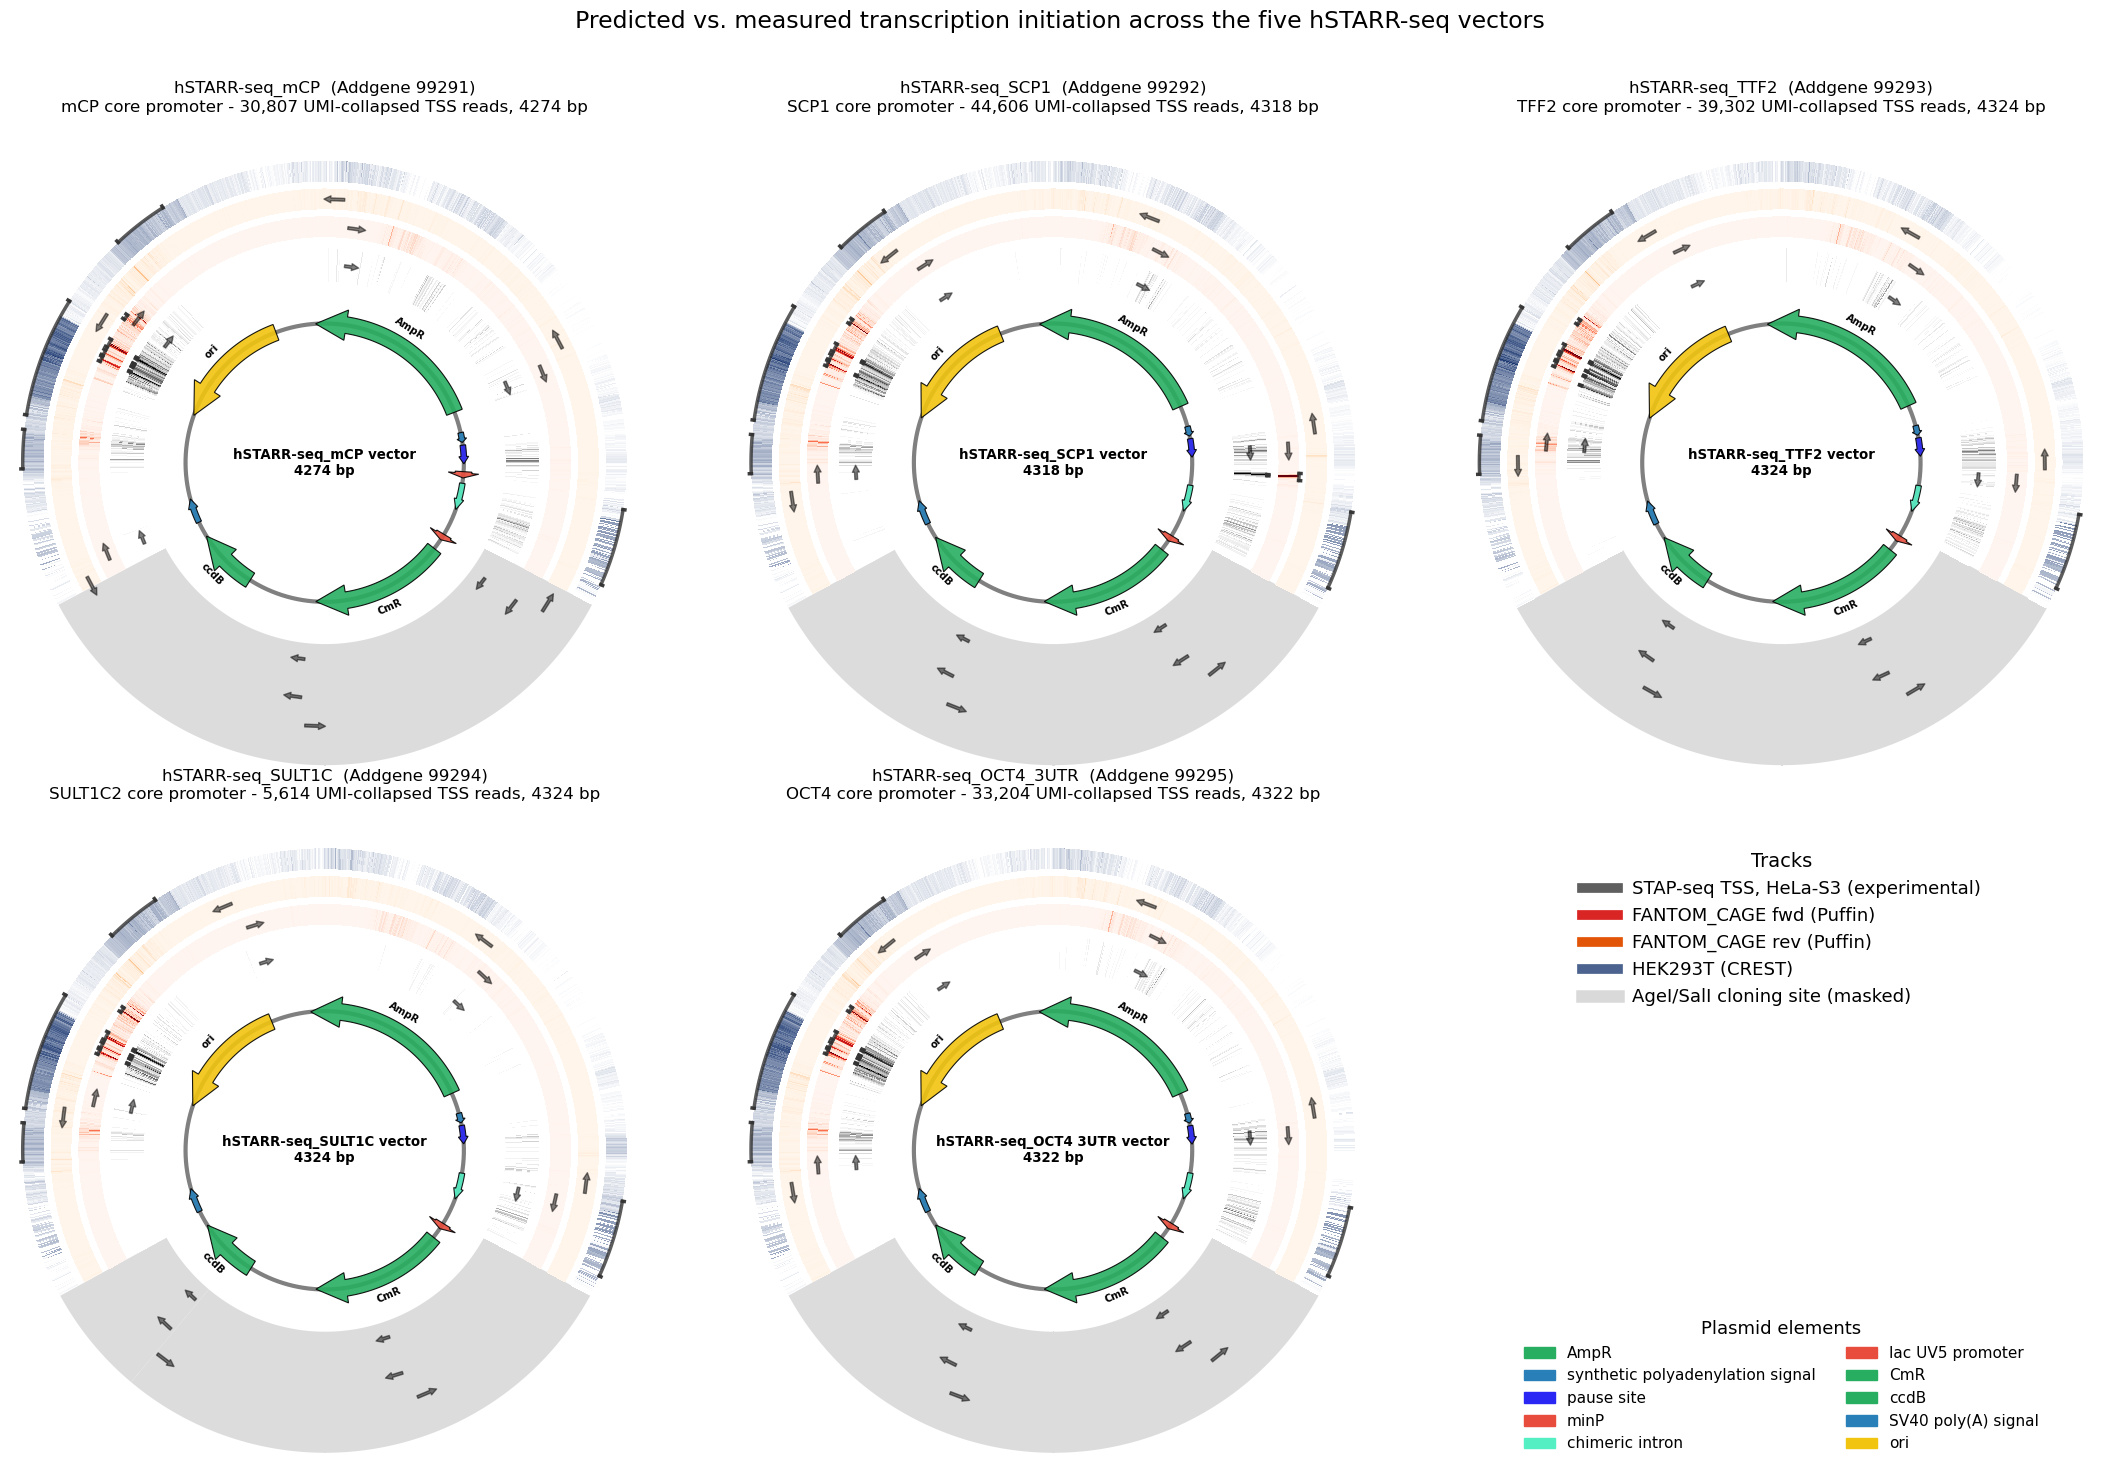

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(22, 15), subplot_kw={"projection": "polar"})
for ax_panel, plasmid_id in zip(axes.flat, PANEL_PLASMIDS):
    draw_panel(ax_panel, plasmid_id)

# Sixth slot carries the shared legends rather than repeating them per panel.
legend_ax = axes.flat[len(PANEL_PLASMIDS)]
legend_ax.axis("off")

track_legend = legend_ax.legend(
    handles=track_legend_handles(),
    loc="upper center", frameon=False, fontsize=13, title="Tracks", title_fontsize=14,
)
legend_ax.add_artist(track_legend)

# Union of plasmid elements across the five panels; the sets differ slightly
# (only the mCP vector carries minP), so dedupe on the label.
element_handles = {}
for ax_panel in axes.flat[: len(PANEL_PLASMIDS)]:
    for patch in ax_panel.plasmid_element_handles:
        element_handles.setdefault(patch.get_label(), patch)
legend_ax.legend(
    handles=list(element_handles.values()),
    loc="lower center", frameon=False, fontsize=11,
    title="Plasmid elements", title_fontsize=13, ncol=2,
)

fig.suptitle(
    "Predicted vs. measured transcription initiation across the five hSTARR-seq vectors",
    fontsize=17, y=0.98,
)
fig.tight_layout(rect=(0, 0, 1, 0.96))